# 고급 시각화

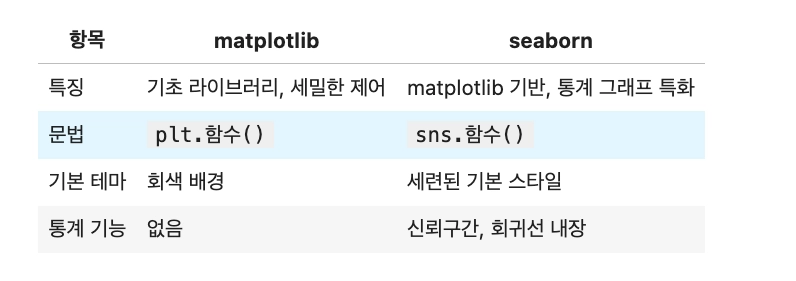

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import platform

if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False
print('환경 설정 완료!')

환경 설정 완료!


In [5]:
plt.rcParams['font.family']

['sans-serif']

### seaborn - barplot

tips 데이터 앞 3행:
(244, 7)
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3


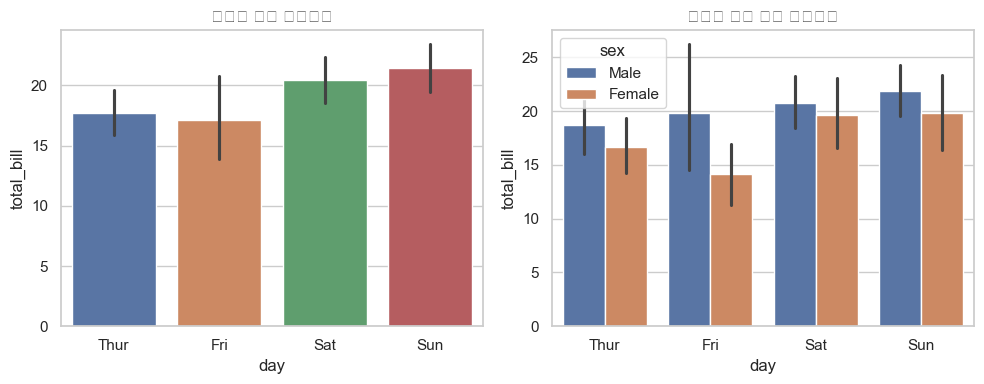

In [3]:
# [예제 1] seaborn barplot (code8_1)
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset('tips')
print('tips 데이터 앞 3행:')
print(df.shape)
print(df.head(3))

sns.set_theme(style='whitegrid', rc={'figure.figsize': (10, 4)})

fig, axes = plt.subplots(1, 2)

# 요일별 평균 청구금액
sns.barplot(data=df, x='day', y='total_bill', estimator='mean',
            hue='day', legend=False, ax=axes[0])
axes[0].set_title('요일별 평균 청구금액')

# 요일별 성별 평균 청구금액
sns.barplot(data=df, x='day', y='total_bill', estimator='mean',
            hue='sex', ax=axes[1])
axes[1].set_title('요일별 성별 평균 청구금액')

plt.tight_layout()
plt.show()

In [ ]:
# [예제 1] seaborn barplot (code8_1)
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset('tips')
print('tips 데이터 앞 3행:')
print(df.shape)
print(df.head(3))


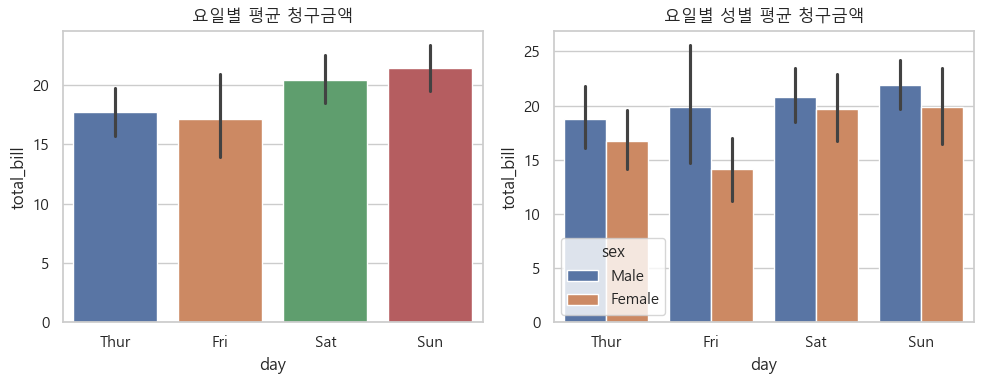

In [6]:
# barplot 생성
sns.set_theme(style='whitegrid', rc={'figure.figsize': (10, 4)})

# set_theme() 실행 시 자체 font 타입으로 리셋되므로 font 형식을 추가해야함
plt.rcParams['font.family'] = 'Malgun Gothic'

fig, axes = plt.subplots(1, 2)

# 요일별 평균 청구금액
sns.barplot(data=df, x='day', y='total_bill', estimator='mean',
            hue='day', legend=False, ax=axes[0])
axes[0].set_title('요일별 평균 청구금액')

# 요일별 성별 평균 청구금액
sns.barplot(data=df, x='day', y='total_bill', estimator='mean',
            hue='sex', ax=axes[1])
axes[1].set_title('요일별 성별 평균 청구금액')

plt.tight_layout()
plt.show()

In [8]:
# [실습] seaborn - barplot : iris 품종별 평균 꽃잎 길이
# x : 품종, y: 꽃잎길이
# font: plt.rcParams['font.family'] = 'Malgun Gothic'
df = pd.read_csv('data/iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


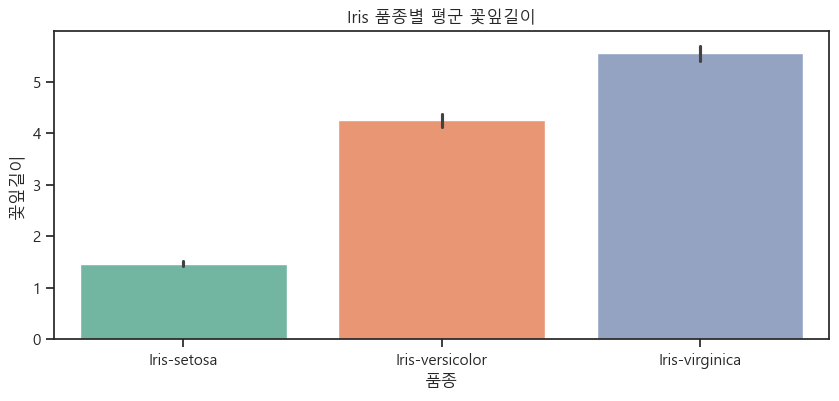

In [10]:
sns.set_theme(style='ticks', rc={'figure.figsize': (10, 4)})
plt.rcParams['font.family'] = 'Malgun Gothic'

sns.barplot(
    data=df,
    x='Species',
    y='PetalLengthCm',
    estimator='mean',
    hue='Species',
    palette='Set2',
    legend=False
)
plt.title('Iris 품종별 평군 꽃잎길이')
plt.xlabel('품종')
plt.ylabel('꽃잎길이')
plt.show()

### seaborn lineplot — 월별 항공 탑승객

In [11]:
flights = sns.load_dataset('flights')
flights.shape
flights.head()


,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


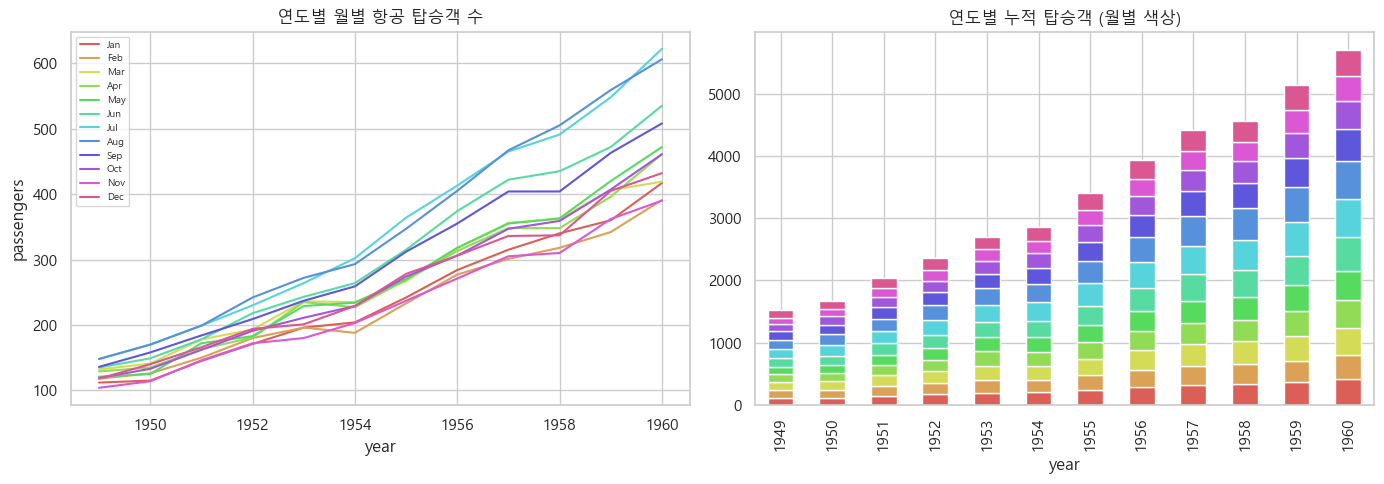

In [12]:
sns.set_theme(style='whitegrid', rc={'figure.figsize': (10, 4)})
sns.set_palette('hls', 12)

plt.rcParams['font.family'] = 'Malgun Gothic'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 선그래프
sns.lineplot(data=flights, x='year', y='passengers',
             hue='month', ax=axes[0])
axes[0].set_title('연도별 월별 항공 탑승객 수')
axes[0].legend(loc='upper left', fontsize=7)

# 누적 막대그래프
df2 = flights.pivot_table(index='year', columns='month',
                          values='passengers', aggfunc='mean')
df2.plot.bar(stacked=True, ax=axes[1], legend=False)
axes[1].set_title('연도별 누적 탑승객 (월별 색상)')

plt.tight_layout()
plt.show()

### seaborn boxplot — 서울 기온

In [15]:
df = pd.read_csv('data/OBS_ASOS_DD_20250101.csv')
df.head()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181 entries, 0 to 180
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   지점        181 non-null    int64  
 1   지점명       181 non-null    object 
 2   일시        181 non-null    object 
 3   평균기온(°C)  181 non-null    float64
dtypes: float64(1), int64(1), object(2)
memory usage: 5.8+ KB


In [18]:
df['일시'] = pd.to_datetime(df['일시'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181 entries, 0 to 180
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   지점        181 non-null    int64         
 1   지점명       181 non-null    object        
 2   일시        181 non-null    datetime64[ns]
 3   평균기온(°C)  181 non-null    float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 5.8+ KB


In [22]:
# '일시 ' 컬럼을 year, month, day 컬럼으로 분리
df['year'] = df['일시'].dt.year
df['month'] = df['일시'].dt.month
df['day'] = df['일시'].dt.day
df.head()

,지점,지점명,일시,평균기온(°C),year,month,day
0,108,서울,2025-01-01,2.6,2025,1,1
1,108,서울,2025-01-02,0.5,2025,1,2
2,108,서울,2025-01-03,-1.1,2025,1,3
3,108,서울,2025-01-04,-0.1,2025,1,4
4,108,서울,2025-01-05,1.2,2025,1,5


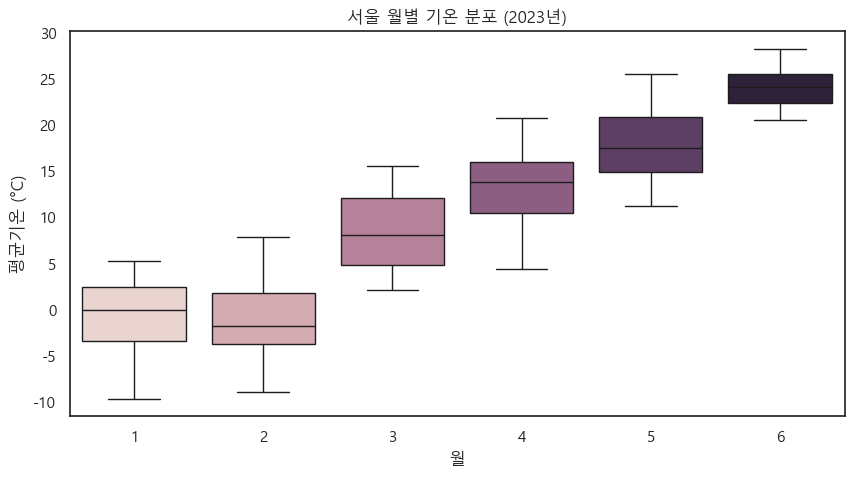

In [24]:
sns.set_theme(style='white', rc={'figure.figsize': (10, 5)})
plt.rcParams['font.family'] = 'Malgun Gothic'
sns.boxplot(data=df, x='month', y='평균기온(°C)',
            hue='month', legend=False)
sns.color_palette("husl", 9)
plt.title('서울 월별 기온 분포 (2023년)')
plt.xlabel('월')
plt.ylabel('평균기온 (°C)')
plt.show()


In [32]:
# [실습] 2016년~2025년 까지의 평균 기온, 평균 습도를 boxplot으로 생성하여 한 행에 두 개 그래프 생성
# 년도 기준 그룹
# x : 년도, y : 평균 기온, 평균 습도
# 년도별 박스 색상 다르게 표현

df = pd.read_csv('data/OBS_ASOS_MNH_20260623133953.csv')
df.head()

df['일시'] = pd.to_datetime(df['일시'])
df['년도'] = df['일시'].dt.year
df.head()
# df['년도'].value_counts()

,지점,지점명,일시,평균기온(°C),평균상대습도(%),평균풍속(m/s),평균지면온도(°C),년도
0,108,서울,2016-01-01,-3.2,53,2.5,-1.4,2016
1,108,서울,2016-02-01,0.2,52,2.8,1.1,2016
2,108,서울,2016-03-01,7.0,51,2.4,9.1,2016
3,108,서울,2016-04-01,14.1,55,2.4,17.0,2016
4,108,서울,2016-05-01,19.6,56,2.4,23.2,2016


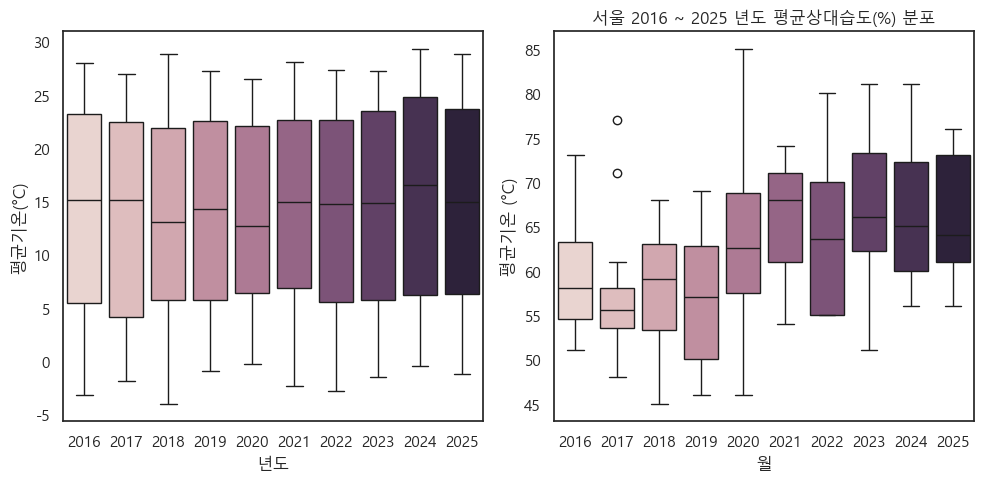

In [33]:
fig, axes = plt.subplots(1, 2)

# 평균 기온
sns.set_theme(style='white', rc={'figure.figsize': (10, 5)})
plt.rcParams['font.family'] = 'Malgun Gothic'
sns.boxplot(data=df, x='년도', 
            y='평균기온(°C)',
            hue='년도', 
            legend=False,
            ax = axes[0])
sns.color_palette("husl", 12)
plt.title('서울 2016 ~ 2025 년도 기온 분포')
plt.xlabel('월')
plt.ylabel('평균기온 (°C)')

# 평균 습도
sns.set_theme(style='white', rc={'figure.figsize': (10, 5)})
plt.rcParams['font.family'] = 'Malgun Gothic'
sns.boxplot(data=df, x='년도', 
            y='평균상대습도(%)',
            hue='년도', 
            legend=False,
            ax = axes[1])
sns.color_palette("husl", 12)
plt.title('서울 2016 ~ 2025 년도 평균상대습도(%) 분포')
plt.xlabel('월')
plt.ylabel('평균기온 (°C)')

plt.tight_layout()
plt.show()


In [34]:
df = pd.read_csv('data/crimeRatesByState2005.csv')
print('컬럼:', df.columns.tolist())
print(df.head(3))

컬럼: ['state', 'murder', 'forcible_rape', 'robbery', 'aggravated_assault', 'burglary', 'larceny_theft', 'motor_vehicle_theft', 'population']
     state  murder  forcible_rape  robbery  aggravated_assault  burglary  \
0  Alabama     8.2           34.3    141.4               247.8     953.8   
1   Alaska     4.8           81.1     80.9               465.1     622.5   
2  Arizona     7.5           33.8    144.4               327.4     948.4   

   larceny_theft  motor_vehicle_theft  population  
0         2650.0                288.3     4545049  
1         2599.1                391.0      669488  
2         2965.2                924.4     5974834  


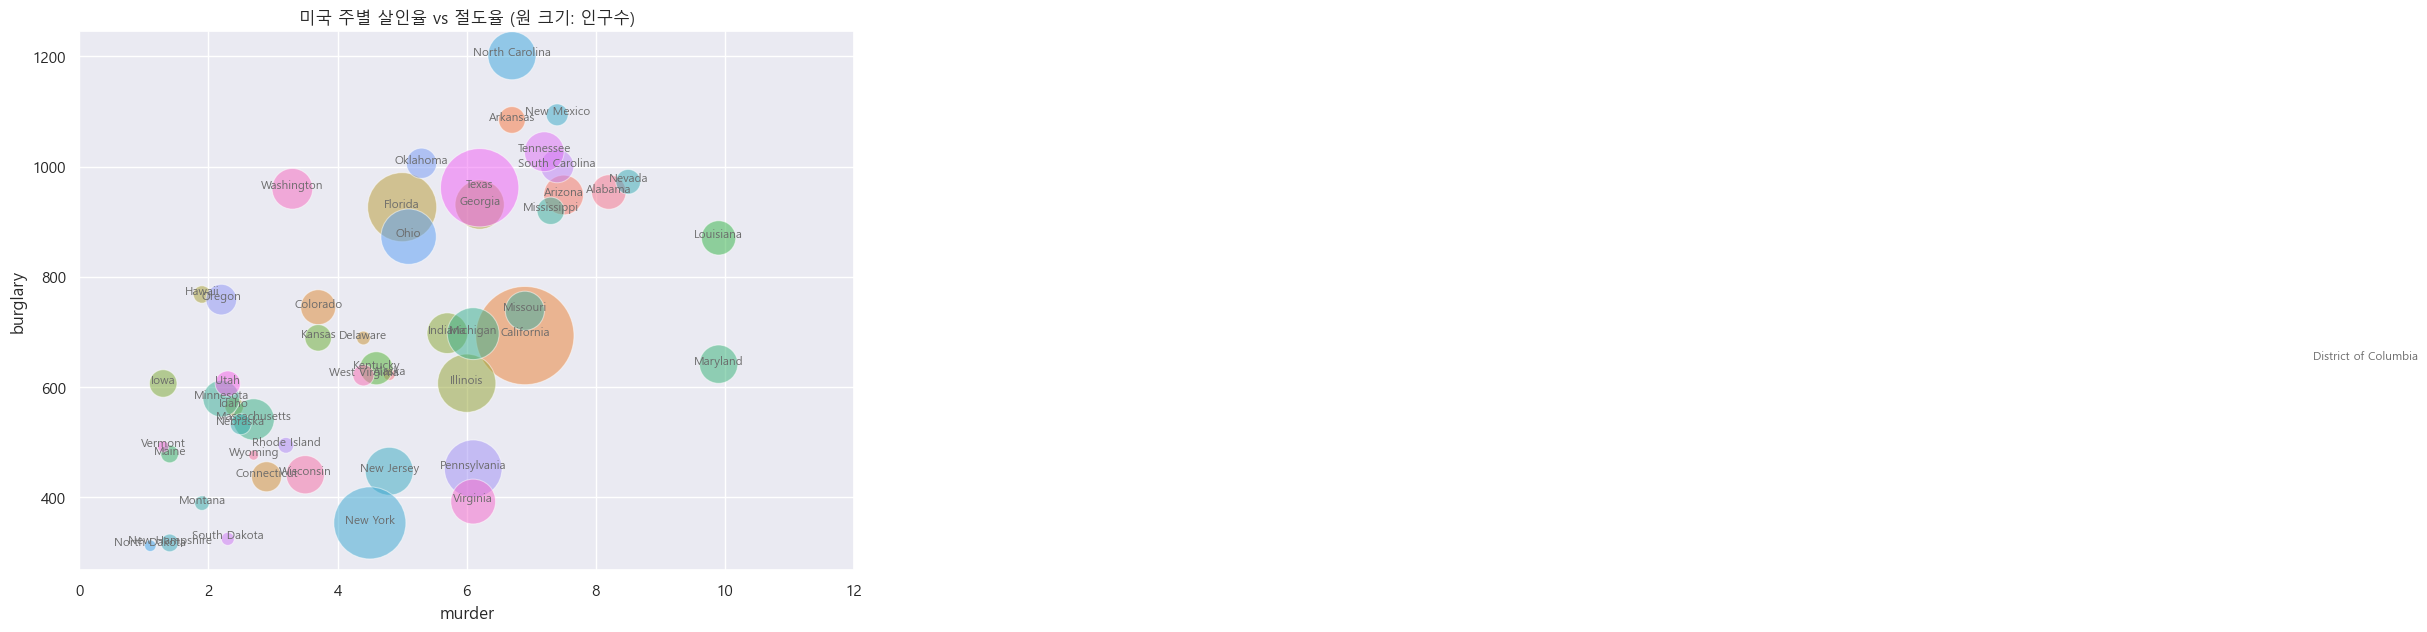

In [38]:
sns.set_theme(rc={'figure.figsize': (10, 7)})
plt.rcParams['font.family'] = 'Malgun Gothic'
sns.scatterplot(data=df, x='murder', y='burglary',
                size='population', sizes=(50, 5000),
                hue='state', alpha=0.5, legend=False)
plt.xlim(0, 12)
plt.title('미국 주별 살인율 vs 절도율 (원 크기: 인구수)')

# 주 이름 레이블
for i in range(len(df)):
    plt.text(df.murder.iloc[i], df.burglary.iloc[i], df.state.iloc[i],
             ha='center', size='x-small', color='dimgray')
plt.show()

In [39]:
df = sns.load_dataset('titanic')

In [40]:
df = df.replace({'survived': {0: '사망', 1: '생존'}})
df = df.replace({'sex': {'male': '남성', 'female': '여성'}})

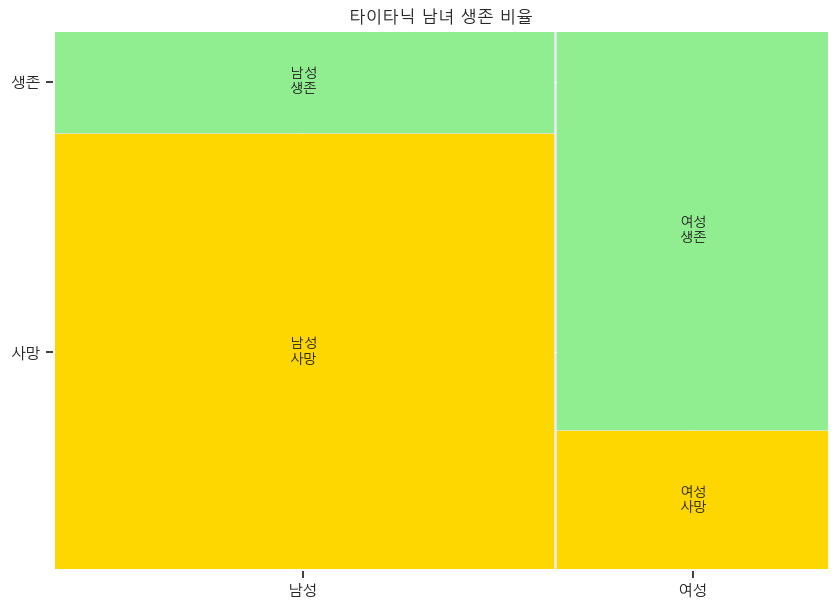

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.graphics.mosaicplot import mosaic
import platform

props = lambda key: {'color': 'lightgreen' if '생존' in key else 'gold'}

mosaic(data=df.sort_values('sex'),
       index=['sex', 'survived'],
       properties=props,
       axes_label=True,
       title='타이타닉 남녀 생존 비율')
plt.show()

In [44]:
flights = sns.load_dataset('flights')

In [45]:
pivot = flights.pivot_table(index='month', columns='year',
                            values='passengers', aggfunc='mean')


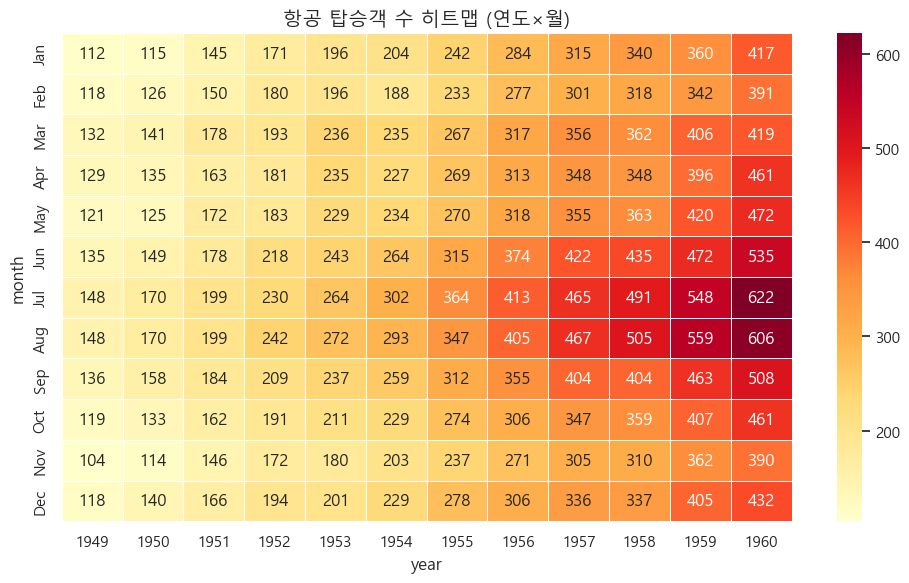

In [54]:
sns.set_theme(rc={'figure.figsize': (10, 6)})
plt.rcParams['font.family'] = 'Malgun Gothic'
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5)
plt.title('항공 탑승객 수 히트맵 (연도×월)', fontsize=14)
plt.tight_layout()
plt.show()

### plotly treemap — 국가별 인구/GNI

In [47]:
import plotly.express as px

In [48]:
df = pd.read_csv('data/GNI2014.csv')
print('컬럼:', df.columns.tolist())
print(df.head(3))

컬럼: ['iso3', 'country', 'continent', 'population', 'GNI']
  iso3  country      continent  population     GNI
0  BMU  Bermuda  North America       67837  106140
1  NOR   Norway         Europe     4676305  103630
2  QAT    Qatar           Asia      833285   92200


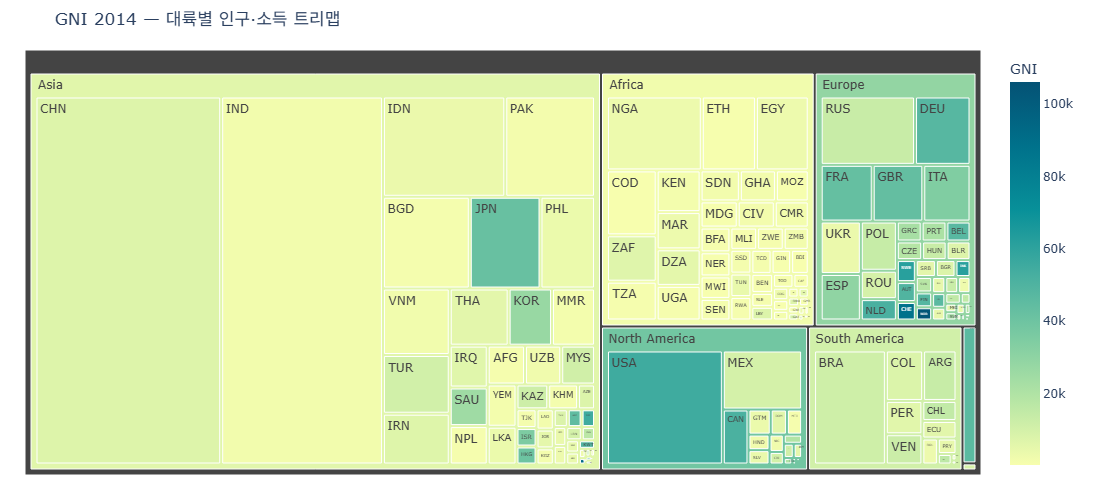

In [49]:
fig = px.treemap(
    data_frame=df,
    path=['continent', 'iso3'],   # 계층 구조: 대륙 → 국가
    values='population',          # 타일 면적
    color='GNI',                  # 색상 강도
    color_continuous_scale='Bluyl',
    title='GNI 2014 — 대륙별 인구·소득 트리맵'
)
fig.update_layout(margin=dict(t=50, l=25, r=25, b=25), width=800, height=500)
fig.show()

In [50]:
from statsmodels.graphics.mosaicplot import mosaic
import platform

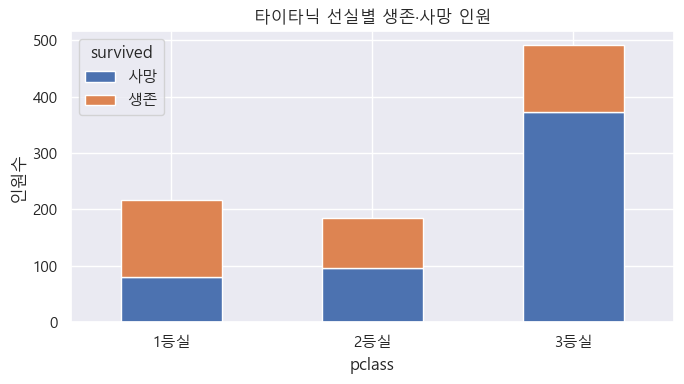

In [55]:
df = sns.load_dataset('titanic')
plt.rcParams['font.family'] = 'Malgun Gothic'
df = df.replace({'survived': {0: '사망', 1: '생존'}})
df = df.replace({'pclass': {1: '1등실', 2: '2등실', 3: '3등실'}})


df2 = df.pivot_table(index='pclass', columns='survived',
                     values='alone', aggfunc='count')
df2.plot.bar(stacked=True, figsize=(7, 4), rot=0,
             title='타이타닉 선실별 생존·사망 인원')
plt.ylabel('인원수')
plt.tight_layout()
plt.show()

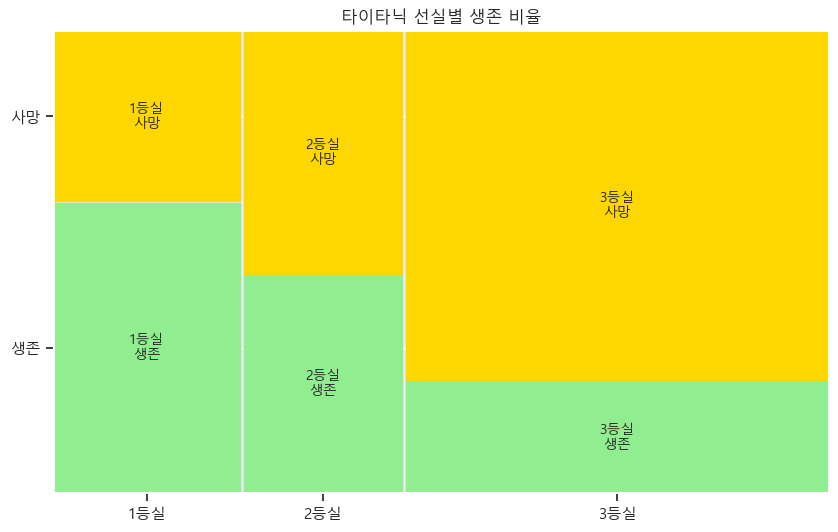

In [56]:
props = lambda key: {'color': 'lightgreen' if '생존' in key else 'gold'}
plt.rcParams['font.family'] = 'Malgun Gothic'
mosaic(data=df.sort_values('pclass'), index=['pclass', 'survived'],
       properties=props, axes_label=True,
       title='타이타닉 선실별 생존 비율')
plt.show()

### heatmap — iris 상관계수 행렬 시각화

**조건**

1. `iris.csv`의 수치형 컬럼 4개의 **상관계수 행렬**을 계산한다
2. `sns.heatmap()`으로 시각화한다
3. 각 셀에 상관계수 값을 표시하고(`annot=True`), 색상 팔레트는 `'coolwarm'`을 사용한다
4. 대각선 색상을 통해 완전 상관(`1.0`)임을 확인하고 Markdown 셀에 해석 한 줄을 작성한다

In [60]:
df = pd.read_csv('data/iris.csv')
df.head()
df_num = df.drop(columns='Species')
df_num.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,1,5.1,3.5,1.4,0.2
1,2,4.9,3.0,1.4,0.2
2,3,4.7,3.2,1.3,0.2
3,4,4.6,3.1,1.5,0.2
4,5,5.0,3.6,1.4,0.2


In [62]:
df_corr = df_num.corr().round(2)

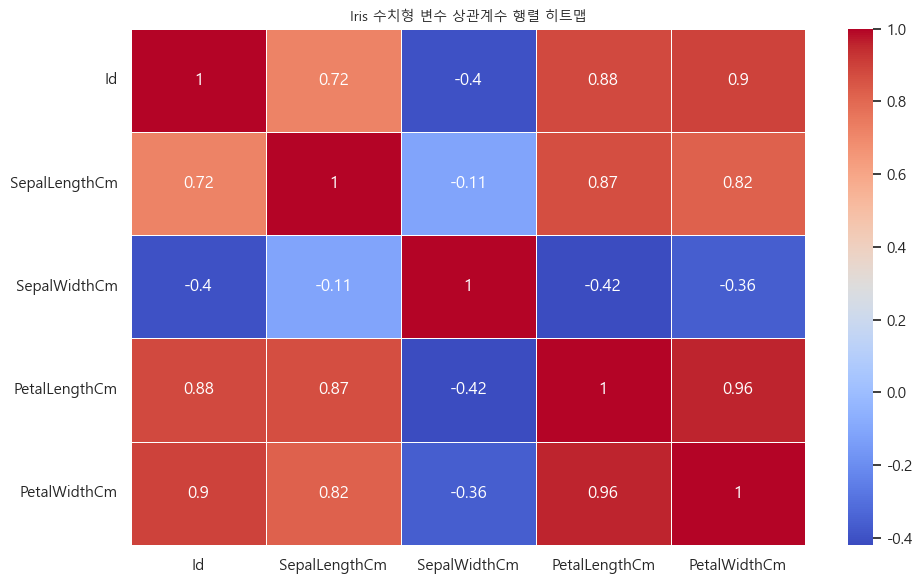

In [64]:
sns.set_theme(rc={'figure.figsize': (10, 6)})
plt.rcParams['font.family'] = 'Malgun Gothic'

sns.heatmap(df_corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Iris 수치형 변수 상관계수 행렬 히트맵', fontsize=10)
plt.tight_layout()
plt.show()

### heatmap — mpg 상관계수 행렬 시각화

In [65]:
df = pd.read_csv('data/mpg.csv')
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [67]:
df_num = df.drop(columns=['horsepower', 'car name'])

In [69]:
df_corr = df_num.corr().round(2)

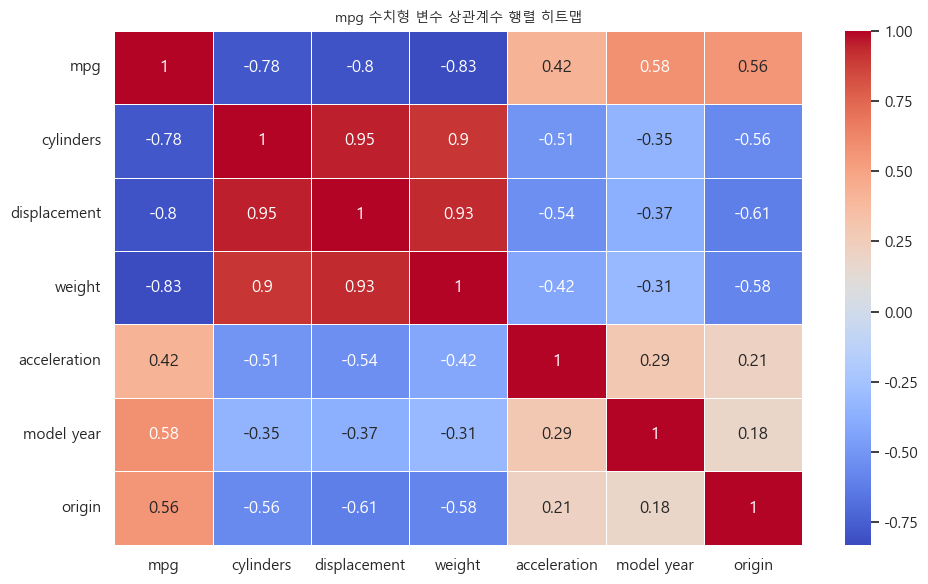

In [71]:
sns.set_theme(rc={'figure.figsize': (10, 6)})
plt.rcParams['font.family'] = 'Malgun Gothic'

sns.heatmap(df_corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('mpg 수치형 변수 상관계수 행렬 히트맵', fontsize=10)
plt.tight_layout()
plt.show()

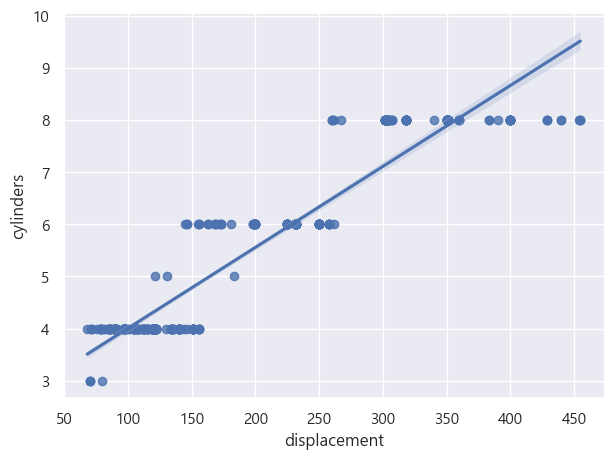

In [73]:
plt.figure(figsize=(7,5))
sns.regplot(
    data=df,
    x='displacement',
    y='cylinders'
)
plt.show()